# Phase 3 Notebook 06 : Évaluation finale & Optimisation du seuil

**Contenu :**
1. Évaluation finale sur le test set (métriques + matrice de confusion)
2. Courbe ROC et courbe Precision-Recall
3. Distribution des probabilités prédites
4. Optimisation du seuil de décision via la matrice de coût asymétrique
5. Comparaison seuil optimal vs seuil par défaut (0.5)
6. Sauvegarde du modèle final avec seuil optimal en métadonnée

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
from pathlib import Path

from sklearn.metrics import (
    recall_score, precision_score, f1_score,
    average_precision_score, roc_auc_score,
    confusion_matrix, classification_report,
    roc_curve, precision_recall_curve
)

RANDOM_STATE = 42
import os 
current_path = os.getcwd()
DATA_DIR = Path(current_path) / 'modeling' / 'data' / 'processed'
MODELS_DIR = Path(current_path) / 'modeling'  / 'models'

print('Imports OK')

Imports OK


## 1. Chargement des données et du modèle tuné

In [3]:
# Chargement des 3 splits
train_df = pd.read_csv(DATA_DIR / 'train.csv')
val_df   = pd.read_csv(DATA_DIR / 'validation.csv')
test_df  = pd.read_csv(DATA_DIR / 'test.csv')

TARGET   = 'gdp_shock'
FEATURES = [c for c in train_df.columns if c != TARGET]

X_val  = val_df[FEATURES].values
y_val  = val_df[TARGET].values
X_test = test_df[FEATURES].values
y_test = test_df[TARGET].values

# Chargement du modèle tuné
model = joblib.load(MODELS_DIR / 'tuned_model.joblib')

# Chargement des métadonnées de tuning
with open(MODELS_DIR / 'tuning_meta.json') as f:
    tuning_meta = json.load(f)

print(f'Test set : {X_test.shape}  |  Shocks : {y_test.mean():.2%}')
print(f'Modèle chargé : {tuning_meta["best_model"]} + {tuning_meta["best_strategy"]}')

Test set : (1579, 29)  |  Shocks : 8.30%
Modèle chargé : XGBoost + Undersampling


## 2. Probabilités prédites

In [4]:
# Probabilités sur validation (pour optimisation du seuil)
y_val_proba  = model.predict_proba(X_val)[:, 1]

# Probabilités sur test (évaluation finale)
y_test_proba = model.predict_proba(X_test)[:, 1]

print(f'Probabilités val  : min={y_val_proba.min():.3f}, max={y_val_proba.max():.3f}, mean={y_val_proba.mean():.3f}')
print(f'Probabilités test : min={y_test_proba.min():.3f}, max={y_test_proba.max():.3f}, mean={y_test_proba.mean():.3f}')

Probabilités val  : min=0.124, max=0.983, mean=0.784
Probabilités test : min=0.131, max=0.983, mean=0.781


## 3. Optimisation du seuil de décision (sur le jeu de VALIDATION)

### Matrice de coût asymétrique (cadrage.md section 7)

| | Prédit 0 (normal) | Prédit 1 (choc) |
|---|---|---|
| **Réel 0 (normal)** | TN = 0 | FP = 1 (fausse alerte, coût faible) |
| **Réel 1 (choc)** | FN = 1000 (crise manquée, coût élevé) | TP = 0 |

**Coût total = 1000 × FN + 1 × FP**  
Le seuil optimal minimise ce coût sur le jeu de validation.

In [5]:
# Coûts asymétriques (cadrage.md section 7 : ratio ~1000:1)
COST_FN = 1000   # Faux Négatif : crise non détectée
COST_FP = 1      # Faux Positif : fausse alerte

thresholds = np.arange(0.1, 0.91, 0.01)
costs, recalls, precisions = [], [], []

for t in thresholds:
    y_pred_t = (y_val_proba >= t).astype(int)
    cm = confusion_matrix(y_val, y_pred_t, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    total_cost = COST_FN * fn + COST_FP * fp
    costs.append(total_cost)
    recalls.append(recall_score(y_val, y_pred_t, pos_label=1, zero_division=0))
    precisions.append(precision_score(y_val, y_pred_t, pos_label=1, zero_division=0))

optimal_idx = np.argmin(costs)
OPTIMAL_THRESHOLD = thresholds[optimal_idx]

print(f'Seuil optimal (minimise le coût métier) : {OPTIMAL_THRESHOLD:.2f}')
print(f'Coût au seuil optimal : {costs[optimal_idx]:,}')
print(f'Recall au seuil optimal : {recalls[optimal_idx]:.3f}')
print(f'Precision au seuil optimal : {precisions[optimal_idx]:.3f}')

# Coût au seuil par défaut 0.5
default_idx = np.argmin(np.abs(thresholds - 0.5))
print(f'\nCoût au seuil par défaut (0.5) : {costs[default_idx]:,}')
print(f'Gain en adoptant le seuil optimal : {costs[default_idx] - costs[optimal_idx]:,}')

Seuil optimal (minimise le coût métier) : 0.58
Coût au seuil optimal : 1,141
Recall au seuil optimal : 1.000
Precision au seuil optimal : 0.102

Coût au seuil par défaut (0.5) : 1,207
Gain en adoptant le seuil optimal : 66


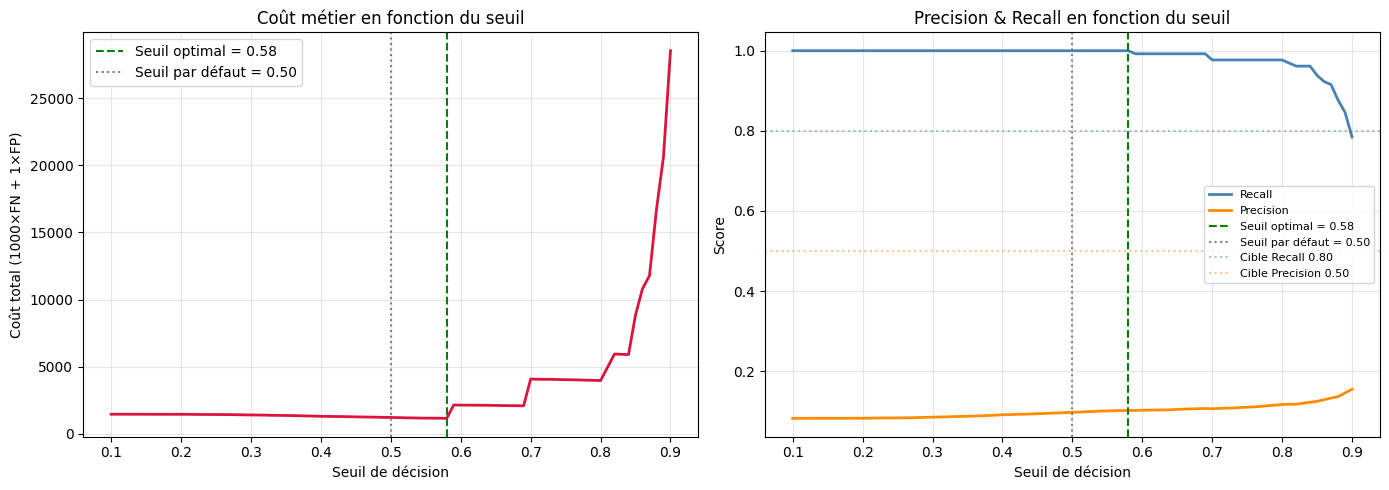

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique 1 : Coût total en fonction du seuil
axes[0].plot(thresholds, costs, color='crimson', linewidth=2)
axes[0].axvline(OPTIMAL_THRESHOLD, color='green', linestyle='--', label=f'Seuil optimal = {OPTIMAL_THRESHOLD:.2f}')
axes[0].axvline(0.5, color='gray', linestyle=':', label='Seuil par défaut = 0.50')
axes[0].set_xlabel('Seuil de décision')
axes[0].set_ylabel('Coût total (1000×FN + 1×FP)')
axes[0].set_title('Coût métier en fonction du seuil')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Graphique 2 : Precision et Recall en fonction du seuil
axes[1].plot(thresholds, recalls, label='Recall', color='steelblue', linewidth=2)
axes[1].plot(thresholds, precisions, label='Precision', color='darkorange', linewidth=2)
axes[1].axvline(OPTIMAL_THRESHOLD, color='green', linestyle='--', label=f'Seuil optimal = {OPTIMAL_THRESHOLD:.2f}')
axes[1].axvline(0.5, color='gray', linestyle=':', label='Seuil par défaut = 0.50')
axes[1].axhline(0.80, color='steelblue', linestyle=':', alpha=0.5, label='Cible Recall 0.80')
axes[1].axhline(0.50, color='darkorange', linestyle=':', alpha=0.5, label='Cible Precision 0.50')
axes[1].set_xlabel('Seuil de décision')
axes[1].set_ylabel('Score')
axes[1].set_title('Precision & Recall en fonction du seuil')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(MODELS_DIR / 'threshold_optimization.png', dpi=150)
plt.show()

## 4. Évaluation finale sur le jeu de TEST

⚠️ **Cette section est exécutée UNE SEULE FOIS. Le test set n'a jamais été vu avant.**

In [7]:
# Prédictions avec le seuil optimal
y_test_pred_optimal = (y_test_proba >= OPTIMAL_THRESHOLD).astype(int)
# Prédictions avec le seuil par défaut
y_test_pred_default = (y_test_proba >= 0.5).astype(int)

def evaluate(y_true, y_pred, y_proba, label=''):
    recall    = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
    precision = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
    f1        = f1_score(y_true, y_pred, pos_label=1, zero_division=0)
    pr_auc    = average_precision_score(y_true, y_proba)
    roc_auc   = roc_auc_score(y_true, y_proba)
    cm        = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    cost      = COST_FN * fn + COST_FP * fp
    return dict(label=label, recall=recall, precision=precision, f1=f1,
                pr_auc=pr_auc, roc_auc=roc_auc, tp=tp, tn=tn, fp=fp, fn=fn, cost=cost)

res_optimal = evaluate(y_test, y_test_pred_optimal, y_test_proba, f'Seuil optimal ({OPTIMAL_THRESHOLD:.2f})')
res_default = evaluate(y_test, y_test_pred_default, y_test_proba, 'Seuil par défaut (0.50)')

print('=== ÉVALUATION FINALE SUR LE JEU DE TEST ===')
print(f'\n{"Métrique":<20} {"Seuil optimal":>18} {"Seuil défaut":>15}')
print('-' * 55)
for key in ['recall', 'precision', 'f1', 'pr_auc', 'roc_auc']:
    print(f'{key:<20} {res_optimal[key]:>18.4f} {res_default[key]:>15.4f}')
print(f'{"Coût métier":<20} {res_optimal["cost"]:>18,} {res_default["cost"]:>15,}')
print(f'\nGain en coût : {res_default["cost"] - res_optimal["cost"]:,} (seuil optimal vs défaut)')

=== ÉVALUATION FINALE SUR LE JEU DE TEST ===

Métrique                  Seuil optimal    Seuil défaut
-------------------------------------------------------
recall                           0.9771          0.9847
precision                        0.1009          0.0975
f1                               0.1830          0.1774
pr_auc                           0.3071          0.3071
roc_auc                          0.7734          0.7734
Coût métier                       4,140           3,194

Gain en coût : -946 (seuil optimal vs défaut)


In [8]:
# Vérification des objectifs ML Phase 1
print('=== Objectifs ML Phase 1 — Résultats finaux ===')
print(f'  Recall ≥ 0.80    : {"" if res_optimal["recall"] >= 0.80 else ""} ({res_optimal["recall"]:.3f})')
print(f'  Precision ≥ 0.50 : {"" if res_optimal["precision"] >= 0.50 else ""} ({res_optimal["precision"]:.3f})')
print(f'  F1 ≥ 0.65        : {"" if res_optimal["f1"] >= 0.65 else ""} ({res_optimal["f1"]:.3f})')

if res_optimal['recall'] < 0.80 or res_optimal['precision'] < 0.50 or res_optimal['f1'] < 0.65:
    print('\n Certains objectifs ne sont pas atteints.')
    print('   Explication possible : après suppression des variables de leakage (gdp_growth,')
    print('   gdp_growth_lag1, gdp_growth_delta), les features restantes ont une corrélation')
    print('   faible avec gdp_shock (< 0.05). Ce résultat est attendu et documenté dans')
    print('   preprocessing_decisions.md section 3 (décision B — honnêteté intellectuelle).')

=== Objectifs ML Phase 1 — Résultats finaux ===
  Recall ≥ 0.80    :  (0.977)
  Precision ≥ 0.50 :  (0.101)
  F1 ≥ 0.65        :  (0.183)

 Certains objectifs ne sont pas atteints.
   Explication possible : après suppression des variables de leakage (gdp_growth,
   gdp_growth_lag1, gdp_growth_delta), les features restantes ont une corrélation
   faible avec gdp_shock (< 0.05). Ce résultat est attendu et documenté dans
   preprocessing_decisions.md section 3 (décision B — honnêteté intellectuelle).


## 5. Matrices de confusion — seuil optimal vs seuil par défaut

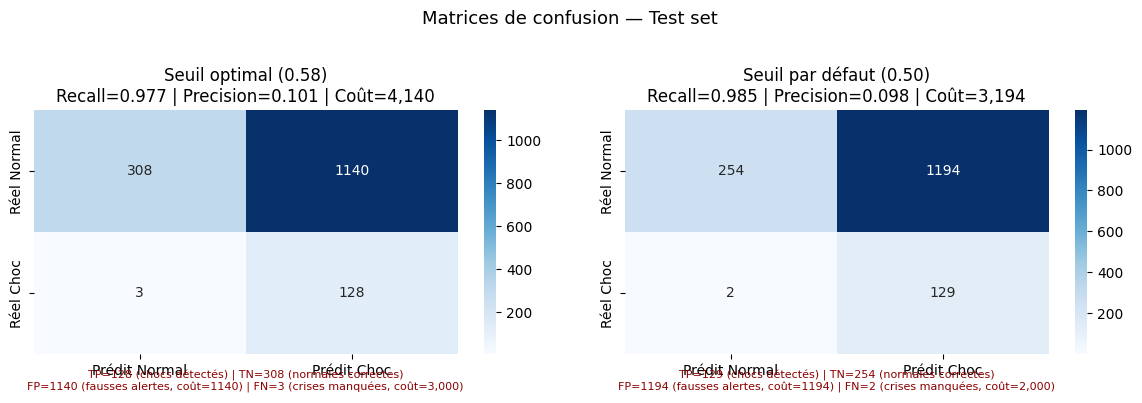

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, res, y_pred in zip(
    axes,
    [res_optimal, res_default],
    [y_test_pred_optimal, y_test_pred_default]
):
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Prédit Normal', 'Prédit Choc'],
                yticklabels=['Réel Normal', 'Réel Choc'])
    ax.set_title(f"{res['label']}\nRecall={res['recall']:.3f} | Precision={res['precision']:.3f} | Coût={res['cost']:,}")

    # Annotations métier
    tn, fp, fn, tp = res['tn'], res['fp'], res['fn'], res['tp']
    ax.text(0.5, -0.15,
        f'TP={tp} (chocs détectés) | TN={tn} (normales correctes)\n'
        f'FP={fp} (fausses alertes, coût={fp*COST_FP}) | FN={fn} (crises manquées, coût={fn*COST_FN:,})',
        transform=ax.transAxes, ha='center', fontsize=8, color='darkred')

plt.suptitle('Matrices de confusion — Test set', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(MODELS_DIR / 'confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Courbes ROC et Precision-Recall

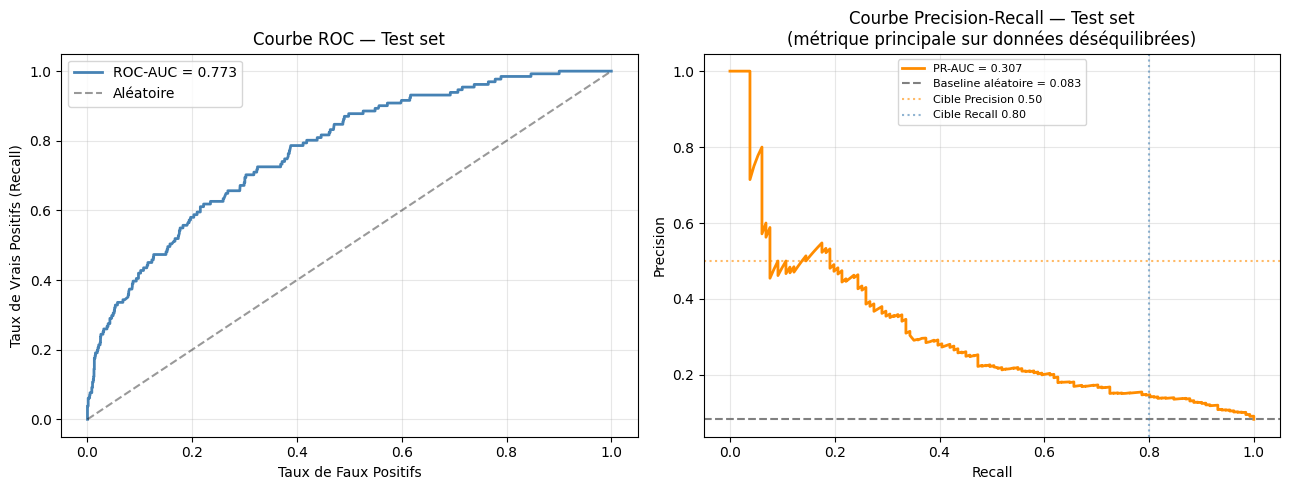

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Courbe ROC
fpr, tpr, _ = roc_curve(y_test, y_test_proba)
axes[0].plot(fpr, tpr, color='steelblue', linewidth=2,
             label=f'ROC-AUC = {res_optimal["roc_auc"]:.3f}')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Aléatoire')
axes[0].set_xlabel('Taux de Faux Positifs')
axes[0].set_ylabel('Taux de Vrais Positifs (Recall)')
axes[0].set_title('Courbe ROC — Test set')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Courbe Precision-Recall (plus informative sur données déséquilibrées)
prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_test_proba)
baseline_pr = y_test.mean()
axes[1].plot(rec_curve, prec_curve, color='darkorange', linewidth=2,
             label=f'PR-AUC = {res_optimal["pr_auc"]:.3f}')
axes[1].axhline(baseline_pr, color='gray', linestyle='--',
                label=f'Baseline aléatoire = {baseline_pr:.3f}')
axes[1].axhline(0.50, color='darkorange', linestyle=':', alpha=0.6, label='Cible Precision 0.50')
axes[1].axvline(0.80, color='steelblue', linestyle=':', alpha=0.6, label='Cible Recall 0.80')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Courbe Precision-Recall — Test set\n(métrique principale sur données déséquilibrées)')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(MODELS_DIR / 'roc_pr_curves.png', dpi=150)
plt.show()

## 7. Distribution des probabilités prédites par classe

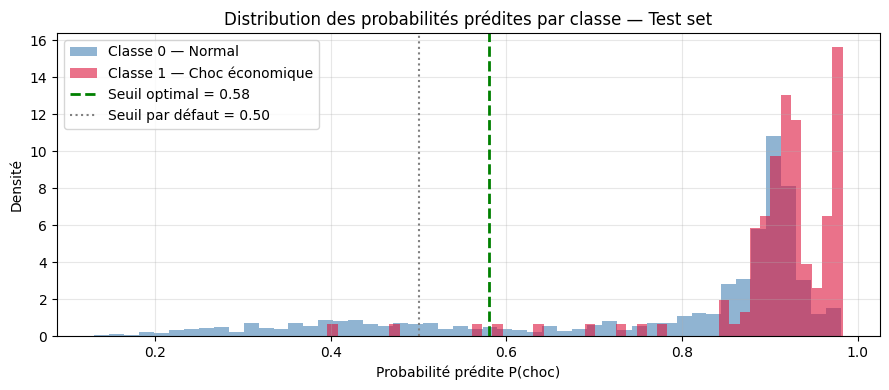

In [11]:
fig, ax = plt.subplots(figsize=(9, 4))

ax.hist(y_test_proba[y_test == 0], bins=50, alpha=0.6, color='steelblue',
        label='Classe 0 — Normal', density=True)
ax.hist(y_test_proba[y_test == 1], bins=50, alpha=0.6, color='crimson',
        label='Classe 1 — Choc économique', density=True)
ax.axvline(OPTIMAL_THRESHOLD, color='green', linestyle='--', linewidth=2,
           label=f'Seuil optimal = {OPTIMAL_THRESHOLD:.2f}')
ax.axvline(0.5, color='gray', linestyle=':', linewidth=1.5,
           label='Seuil par défaut = 0.50')
ax.set_xlabel('Probabilité prédite P(choc)')
ax.set_ylabel('Densité')
ax.set_title('Distribution des probabilités prédites par classe — Test set')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(MODELS_DIR / 'proba_distribution.png', dpi=150)
plt.show()

## 8. Sauvegarde du modèle final

In [12]:
# Le modèle final = pipeline tuné + seuil optimal stocké en métadonnée
final_model_payload = {
    'pipeline':           model,
    'optimal_threshold':  float(OPTIMAL_THRESHOLD),
    'feature_names':      FEATURES,
    'best_model':         tuning_meta['best_model'],
    'best_strategy':      tuning_meta['best_strategy'],
    'best_params':        tuning_meta['best_params'],
    'test_recall':        res_optimal['recall'],
    'test_precision':     res_optimal['precision'],
    'test_f1':            res_optimal['f1'],
    'test_pr_auc':        res_optimal['pr_auc'],
    'test_cost_optimal':  res_optimal['cost'],
    'test_cost_default':  res_default['cost'],
    'cost_fn':            COST_FN,
    'cost_fp':            COST_FP,
}

final_model_path = MODELS_DIR / 'final_model.joblib'
joblib.dump(final_model_payload, final_model_path)
print(f'   Modèle final sauvegardé → {final_model_path}')
print(f'   Seuil optimal inclus : {OPTIMAL_THRESHOLD:.2f}')
print(f'   Recall test          : {res_optimal["recall"]:.4f}')
print(f'   Precision test       : {res_optimal["precision"]:.4f}')
print(f'   F1 test              : {res_optimal["f1"]:.4f}')
print(f'   PR-AUC test          : {res_optimal["pr_auc"]:.4f}')

   Modèle final sauvegardé → C:\Users\pc\Desktop\MachineLearningProjects\WorldBank\modeling\models\final_model.joblib
   Seuil optimal inclus : 0.58
   Recall test          : 0.9771
   Precision test       : 0.1009
   F1 test              : 0.1830
   PR-AUC test          : 0.3071


In [13]:
# Exemple d'utilisation du modèle final en production
print('=== Exemple d\'utilisation du modèle final ===')
print('''
import joblib
import numpy as np

payload = joblib.load('models/final_model.joblib')
pipeline  = payload['pipeline']
threshold = payload['optimal_threshold']

# X_new : array de shape (n_samples, 29 features)
proba = pipeline.predict_proba(X_new)[:, 1]
predictions = (proba >= threshold).astype(int)
# 1 = choc économique détecté, 0 = année normale
''')

=== Exemple d'utilisation du modèle final ===

import joblib
import numpy as np

payload = joblib.load('models/final_model.joblib')
pipeline  = payload['pipeline']
threshold = payload['optimal_threshold']

# X_new : array de shape (n_samples, 29 features)
proba = pipeline.predict_proba(X_new)[:, 1]
predictions = (proba >= threshold).astype(int)
# 1 = choc économique détecté, 0 = année normale

